# Machine Learning Pipeline

## Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn import feature_extraction, linear_model, model_selection, preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## Call cleaned data

In [2]:
f = r"C:\Users\Kajal\Desktop\Fake_News_Project\Data Pre-processing\Cleaned_Data_without_stopwords.csv"
Cleaned_Df = pd.read_csv(f)
Cleaned_Df.head()

,title,text,label,Processed_Content,Processed_Title
0,You Can Smell Hillaryâs Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,"[""'daniel"", 'greenfield', ',', 'shillman', 'jo...","[""'you"", 'smell', 'hillary', 'fear', ""'""]"
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,"[""'google"", 'pinterest', 'dig', 'linkedin', 'r...","[""'watch"", 'exact', 'moment', 'paul', 'ryan', ..."
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,"[""'"", 'u.s', '.', 'secretary', 'state', 'john'...","[""'kerry"", 'go', 'paris', 'gesture', 'sympathy..."
3,Bernie supporters on Twitter erupt in anger ag...,"â Kaydee King (@KaydeeKing) November 9, 2016...",FAKE,"['``', 'kaydee', 'king', '(', 'kaydeeking', ')...","['``', 'bernie', 'supporters', 'twitter', 'eru..."
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,"['``', 'primary', 'day', 'new', 'york', 'front...","[""'the"", 'battle', 'new', 'york', ':', 'primar..."


In [ ]:
# dropping duplicate values 
print("Before removing duplicates, length of data :",len(Cleaned_Df))
Cleaned_Df.drop_duplicates(keep=False,inplace=True) 
print("After dropping duplicate values, length of data :", len(Cleaned_Df))

## Feature Extraction
- This step is crucial because machines do not understand text.
- This step will convert list of tokens into numbers.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vector = TfidfVectorizer(sublinear_tf=True)
tf_vector.fit(Cleaned_Df['Processed_Content'])

TfidfVectorizer(sublinear_tf=True)

## Pipeline for modelling the processed content

In [4]:
X_text = tf_vector.transform(Cleaned_Df['Processed_Content'].ravel())
y_values = np.array(Cleaned_Df['label'].ravel())

## Use label Encoder to transform label text into numbered disgits
- The content can be transformed using TF-IDF vectorizer but we need to transform label column as well since machine don't understand text input.

In [5]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(y_values).transform(y_values)

array([0, 0, 1, ..., 0, 1, 1])

## Split data into training & testing

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_text, y_values, test_size=0.2, random_state=42)

## Modeling

In [15]:
# Function to plot the confusion matrix (code from https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)
from sklearn import metrics
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

## Implementation of Logistic Model

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, y_predict)*100,2)))

accuracy: 93.29%


Confusion matrix, without normalization


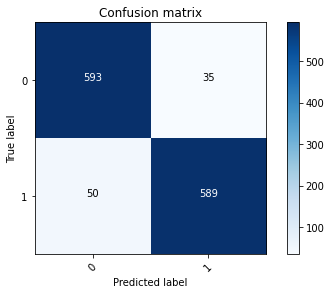

In [18]:
cm = metrics.confusion_matrix(y_test, y_predict)
plot_confusion_matrix(cm, classes=[0, 1])

## Implementation of Decission Tree Classifier

In [70]:
from sklearn.tree import DecisionTreeClassifier

# Fitting the model
model = DecisionTreeClassifier(criterion= 'entropy', max_depth = 20, splitter='best', random_state=50)
model.fit(X_train, y_train)

# Accuracy
y_predict = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, y_predict )*100,2)))

accuracy: 83.03%


Confusion matrix, without normalization


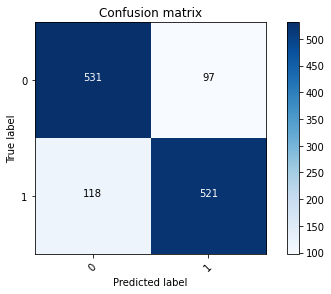

In [71]:
cm = metrics.confusion_matrix(y_test, y_predict)
plot_confusion_matrix(cm, classes=[0, 1])

## Implementation of Random Forest Classifier

In [75]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=1000, criterion="entropy")

model.fit(X_train, y_train)
y_predict = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, y_predict)*100,2)))

accuracy: 92.34%


Confusion matrix, without normalization


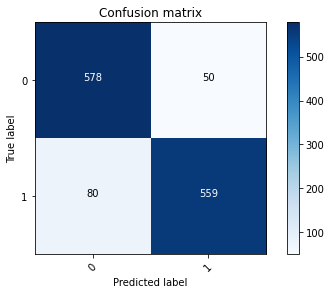

In [33]:
cm = metrics.confusion_matrix(y_test, y_predict)
plot_confusion_matrix(cm, classes=[0, 1])

## Implementation of Passive Aggressive Classifier

In [38]:
from sklearn.linear_model import PassiveAggressiveClassifier
model=PassiveAggressiveClassifier(max_iter=50)
model.fit(X_train, y_train)
#DataFlair - Predict on the test set and calculate accuracy
y_predict = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, y_predict)*100,2)))

accuracy: 95.58%


Confusion matrix, without normalization


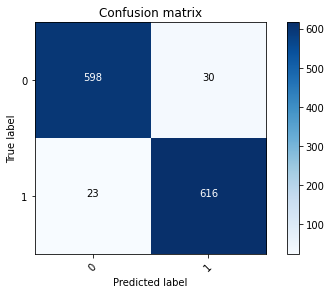

In [35]:
cm = metrics.confusion_matrix(y_test, y_predict)
plot_confusion_matrix(cm, classes=[0, 1])

## Summary:
- Proceesed Data without stopwords performed very well with Passive aggressive classifier with accuracy of 95.82%
- Followed by logistic regression model with accuracy of 93.29%
- Then comes Random forest classifier with accuracy of 89.74% initially, after fine tuning the parameters, it is 92.34%
- And lastly, Decission Tree classifier with 82.64% initially, after fine tuning, it is 83.03%

## Note: 
- If you remember, In our Data Pre-processing step, I have kept two files, One with stopwords and another without stopwords.
- In this tutorial, we have seen the different modeling results for without stopwords file.
- Please check out the other file as well to compare which perform the better with our models.
- Another file is named as "Modelling with Stopwords"